# Static embeddings for semantic usage and change in Latin

Based on https://github.com/BarbaraMcG/latinise/blob/83e9efdd6a216f16d89b4a181a6771c93436549f/lvlt22/Semantic_change.ipynb 

Aims to compare embeddings for Latin words whose meaning widened or specialized under the influence of Christianisation.

To do so, it splits the corpus into subcorpora so as to:
   1. compare embeddings extracted from the pre- and post-christian period
   2. compare embeddings extracted from Christian vs. non-Christian sets of text (within the second time bin)

The notebook is very guided and allows for step-by-step processing and visualisation of results. Just follow along!

## Packages

In [2]:
import os 
import csv
import numpy as np
import pandas as pd
from gensim.models import FastText, Word2Vec
import gensim
from scipy import spatial
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import time
from sklearn.decomposition import PCA
import spacy
import plotly.express as px
import re
from statistics import mean
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
# to make our plot outputs appear and be stored within the notebook:
%matplotlib inline 

## Read the files

Define directories:

In [3]:
# Define directories (relative to project root)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
data_dir = os.path.join(project_root, "data")
corpus_dir = os.path.join(data_dir, "new_lemmatized_texts")
metadata_dir = os.path.join(data_dir, "latinise_metadata_2026.csv")
dir_out = os.path.join(project_root, "static_embeddings", "output")

Define files and count them (the lemmas and tokens are grouped by text, so the number reflects the number of texts):

In [4]:
files = os.listdir(corpus_dir)
len(files)

1153

Read the metadata file:

In [5]:
metadata_df = pd.read_csv((metadata_dir), sep = ",")
metadata_df

,id,title,creator,date_avg,date_range_start,date_range_end,type,file
0,IT-LAT0261,Carmen Saliare,[Auctor incertus],-700,-750.0,-650.0,poetry,lat_0350_IT-LAT0261.txt
1,IT-LAT0285,XII Tabularum Leges,[Auctor incertus],-450,-450.0,-450.0,prose,lat_-0450_IT-LAT0285.txt
2,IT-LAT0262,Carmen Arvale,[Auctor incertus],-350,-400.0,-300.0,poetry,lat_0350_IT-LAT0262.txt
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,-312.0,-279.0,poetry,lat_-0300_MQDQ-288.txt
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,-250.0,-218.0,prose,lat_-0229_IT-LAT1006.txt
...,...,...,...,...,...,...,...,...
1148,IT-LAT0446,Sacramentorum sanctitatis tutela,Ioannes Paulus PP. II,2002,NaN,NaN,prose,lat_2002_IT-LAT0446.txt
1149,IT-LAT0536,Misericordia Dei,Ioannes Paulus PP. II,2002,NaN,NaN,prose,lat_2002_IT-LAT0536.txt
1150,IT-LAT0762,Ecclesia de Eucharistia,Ioannes Paulus PP. II,2003,NaN,NaN,prose,lat_2003_IT-LAT0762.txt
1151,IT-LAT0839,Instructio Redemptionis Sacramentum,Congregatio de Cultu Divino et Disciplina Sacr...,2004,NaN,NaN,prose,lat_2004_IT-LAT0839.txt


Convert date to integer:

In [6]:
date_columns = ["date_avg", "date_range_start", "date_range_end"]

for col in date_columns:
    if col in metadata_df.columns:
        metadata_df[col] = pd.to_numeric(metadata_df[col], errors="coerce").round().astype("Int64")

metadata_df[date_columns].dtypes

date_avg            Int64
date_range_start    Int64
date_range_end      Int64
dtype: object

## Define chronological boundaries and bins

Limit corpus to works to about 600 CE:

In [7]:
metadata_ph = metadata_df[metadata_df['date_range_end'] <= 605].copy()
metadata_ph

,id,title,creator,date_avg,date_range_start,date_range_end,type,file
0,IT-LAT0261,Carmen Saliare,[Auctor incertus],-700,-750,-650,poetry,lat_0350_IT-LAT0261.txt
1,IT-LAT0285,XII Tabularum Leges,[Auctor incertus],-450,-450,-450,prose,lat_-0450_IT-LAT0285.txt
2,IT-LAT0262,Carmen Arvale,[Auctor incertus],-350,-400,-300,poetry,lat_0350_IT-LAT0262.txt
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,-312,-279,poetry,lat_-0300_MQDQ-288.txt
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,-250,-218,prose,lat_-0229_IT-LAT1006.txt
...,...,...,...,...,...,...,...,...
775,MQDQ-188,epitaphium,Marius Auenticentis Episcopus,599,594,604,poetry,lat_0594_MQDQ-188.txt
776,MQDQ-535,carminum appendix,Venantius Fortunatus,587,570,605,poetry,lat_0601_MQDQ-535.txt
777,MQDQ-536,spuriorum appendix,Venantius Fortunatus,587,570,605,poetry,lat_0601_MQDQ-536.txt
778,MQDQ-533,carminum libri 10,Venantius Fortunatus,597,590,605,poetry,lat_0601_MQDQ-533.txt


In [7]:
metadata_ph.to_csv(os.path.join(dir_out, 'metadata_restricted.csv'), index=None)

### Define time intervals (pre-Christian vs Christian)

Find the first and last date in dataset:

In [8]:
first_date = min(metadata_ph.date_range_start)
last_date = max(metadata_ph.date_range_end)
print(first_date)
print(last_date)

-750
605


Define two chronological bins (before 180 CE vs. 180 CE and later):

In [9]:
metadata_ph = metadata_ph.copy()
metadata_ph['era_bin'] = 'post_180'
metadata_ph.loc[metadata_ph['date_range_end'] < 180, 'era_bin'] = 'pre_180'
metadata_ph.loc[metadata_ph['date_range_end'].isna(), 'era_bin'] = 'unknown'

bin_labels = {
    'pre_180': 'date_range_end < 180 CE (exclusive)',
    'post_180': 'date_range_end ≥ 180 CE'
}
bin_labels

{'pre_180': 'date_range_end < 180 CE (exclusive)',
 'post_180': 'date_range_end ≥ 180 CE'}

Count how many works fall into each bin:

In [10]:
era_counts = (
    metadata_ph['era_bin']
    .value_counts()
    .rename_axis('era_bin')
    .to_frame('works')
    .sort_index()
)
era_counts

,works
era_bin,
post_180,393
pre_180,387


Inspect sample rows with their bin assignment:

In [11]:
metadata_ph[['id', 'date_range_end', 'era_bin']].head()

,id,date_range_end,era_bin
0,IT-LAT0261,-650,pre_180
1,IT-LAT0285,-450,pre_180
2,IT-LAT0262,-300,pre_180
3,MQDQ-288,-279,pre_180
4,IT-LAT1006,-218,pre_180


### Count number of tokens by century, by type and by bin
This section creates a 'century' column in the metadata, counts tokens by century, by type (prose/poetry), and by the defined time intervals.

Assign century (derermined by the date at the end of the range, meaning the counts by century might not be totally accurate):

In [12]:
def get_century(year):
    if pd.isnull(year):
        return None
    year = int(year)
    if year < 0:
        return -((abs(year) - 1) // 100 + 1)  # e.g., -1 to -100 = -1 (1st c. BCE), -101 to -200 = -2
    elif year > 0:
        return (year - 1) // 100 + 1  # e.g., 1 to 100 = 1 (1st c. CE), 101 to 200 = 2
    else:
        return None  # year 0 does not exist

metadata_ph['century'] = metadata_ph['date_range_end'].apply(get_century)
metadata_ph['century']

0     -7
1     -5
2     -3
3     -3
4     -3
      ..
775    7
776    7
777    7
778    7
779    7
Name: century, Length: 780, dtype: int64

Define punctuation:

In [13]:
punctuation = set('''!()-[]{};:'"\\,<>./?@#$%^&*_~''')

Count tokens across various categories:

In [14]:
def count_tokens_in_file(file_path, punctuation):
    total_with_punct = 0
    total_without_punct = 0
    try:
        with open(file_path, 'r') as f:
            for line in f:
                tokens = line.split()
                total_with_punct += len(tokens)
                if punctuation:
                    total_without_punct += sum(token not in punctuation for token in tokens)
                else:
                    total_without_punct += len(tokens)
        return total_with_punct, total_without_punct
    except Exception as e:
        print(f"Error reading {file_path}: {e}")
        return 0, 0

corpus_path = Path(corpus_dir)
metadata_source = metadata_ph.copy()

if 'file' not in metadata_source.columns:
    raise ValueError("metadata_ph must include a 'file' column with filenames.")

metadata_source['file'] = metadata_source['file'].astype(str)
available_files = {f for f in metadata_source['file'] if (corpus_path / f).is_file()}

metadata_filtered = metadata_source[
    metadata_source['file'].isin(available_files) & metadata_source['file'].notna()
].copy()
metadata_filtered['type'] = (
    metadata_filtered['type']
    .fillna('unknown')
    .astype(str)
    .str.strip()
    .replace('', 'unknown')
)

skipped_entries = len(metadata_source) - len(metadata_filtered)
if skipped_entries:
    print(f"Skipped {skipped_entries} metadata_ph entries without matching files.")

def count_tokens_for_metadata_row(row):
    file_path = corpus_path / row['file']
    tokens_with_punct, tokens_without_punct = count_tokens_in_file(file_path, punctuation)
    return {
        "id": row["id"],
        "type": row["type"],
        "century": row.get("century"),
        "era_bin": row.get("era_bin"),
        "file": row["file"],
        "tokens_including_punctuation": tokens_with_punct,
        "tokens_excluding_punctuation": tokens_without_punct
    }

records = metadata_filtered.to_dict('records')

token_records = []
with ThreadPoolExecutor() as executor:
    for record in executor.map(count_tokens_for_metadata_row, records):
        token_records.append(record)

token_counts_df = pd.DataFrame(token_records)

if token_counts_df.empty:
    tokens_by_type = pd.DataFrame(
        columns=['tokens_including_punctuation', 'tokens_excluding_punctuation']
    )
    tokens_per_century = pd.Series(dtype='int64')
    tokens_per_bin = pd.DataFrame(
        columns=['tokens_including_punctuation', 'tokens_excluding_punctuation']
    )
    tokens_by_century_type = pd.DataFrame()
    total_tokens_all = 0
    total_tokens_with_punct = 0
    print("No metadata_ph files available for token counting.")
else:
    tokens_by_type = token_counts_df.groupby('type')[
        ['tokens_including_punctuation', 'tokens_excluding_punctuation']
    ].sum().sort_index()
    total_tokens_all = int(token_counts_df['tokens_excluding_punctuation'].sum())
    total_tokens_with_punct = int(token_counts_df['tokens_including_punctuation'].sum())
    tokens_per_century = (
        token_counts_df.dropna(subset=['century'])
        .groupby('century')['tokens_including_punctuation']
        .sum()
        .sort_index()
    )
    tokens_per_bin = (
        token_counts_df.dropna(subset=['era_bin'])
        .groupby('era_bin')[['tokens_including_punctuation', 'tokens_excluding_punctuation']]
        .sum()
        .sort_index()
    )
    tokens_by_century_type = (
        token_counts_df.dropna(subset=['century', 'type'])
        .groupby(['century', 'type'])['tokens_excluding_punctuation']
        .sum()
        .unstack(fill_value=0)
    )

Show some counts:

In [15]:
tokens_by_type

,tokens_including_punctuation,tokens_excluding_punctuation
type,,
poetry,2406280,2021609
prose,5865153,4984831


In [16]:
tokens_per_century

century
-7         29
-5        670
-3       1956
-2     313144
-1    1308192
 1    2190429
 2     846623
 3     497844
 4     666841
 5    1253530
 6    1170439
 7      21736
Name: tokens_including_punctuation, dtype: int64

In [17]:
tokens_by_century_type

type,poetry,prose
century,,
-7,24,0
-5,0,535
-3,1570,28
-2,234514,16700
-1,268770,826509
1,680655,1174079
2,47902,658701
3,37431,381461
4,183046,379687


In [18]:
tokens_per_bin

,tokens_including_punctuation,tokens_excluding_punctuation
era_bin,,
post_180,4025414,3437110
pre_180,4246019,3569330


Count tokens for Cicero's texts (because there are a lot):

In [19]:
# Filter metadata_ph for Cicero
cicero_rows = metadata_ph[metadata_ph['creator'] == 'Cicero, Marcus Tullius']
cicero_files = cicero_rows['file'].tolist()

cicero_token_count = 0
for file_name in cicero_files:
    file_path = os.path.join(corpus_dir, file_name)
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                tokens = [word for word in line.split() if word not in punctuation]
                cicero_token_count += len(tokens)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

print(f"Total tokens in Cicero's texts: {cicero_token_count:,}")


Total tokens in Cicero's texts: 677,035


Visualise counts:

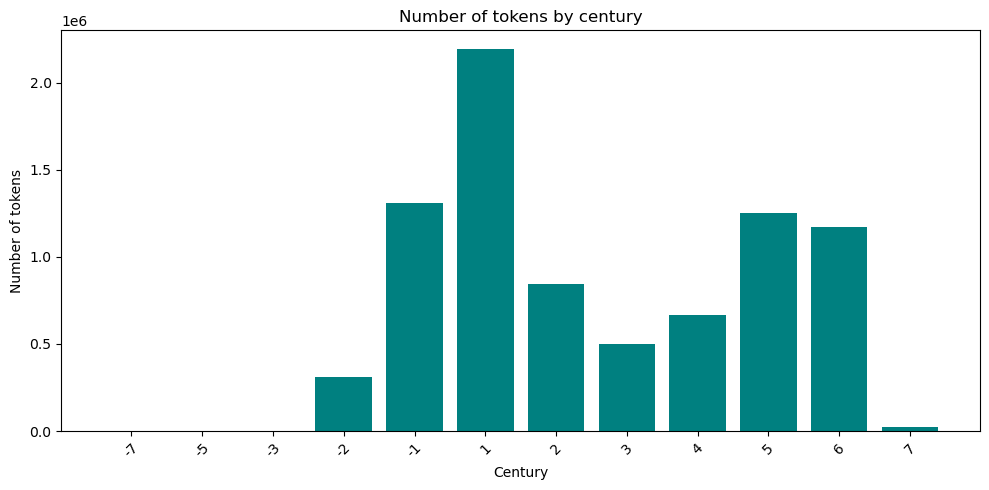

In [20]:
# Plot tokens by century
century_series = tokens_per_century
plt.figure(figsize=(10, 5))
if century_series.empty:
    plt.title('Number of tokens by century')
    plt.text(0.5, 0.5, 'No century data', ha='center', va='center')
    plt.xticks([])
else:
    plt.bar(century_series.index.astype(str), century_series.values, color='teal')
    plt.title('Number of tokens by century')
    plt.xlabel('Century')
    plt.ylabel('Number of tokens')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

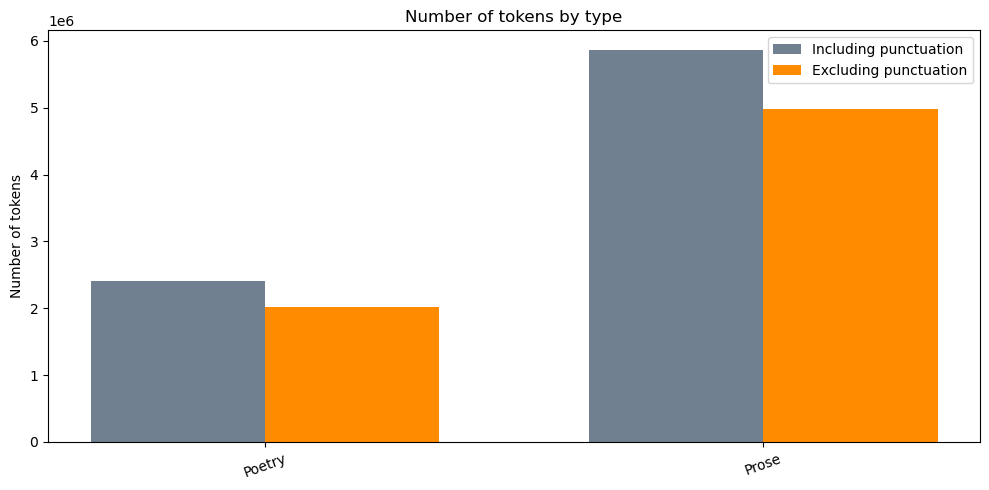

In [21]:
# Plot tokens by type (with and without punctuation)
type_counts = tokens_by_type if 'tokens_by_type' in globals() else pd.DataFrame()
plt.figure(figsize=(10, 5))
if type_counts.empty:
    plt.title('Number of tokens by type')
    plt.text(0.5, 0.5, 'No type data', ha='center', va='center')
    plt.xticks([])
else:
    expected_cols = ['tokens_including_punctuation', 'tokens_excluding_punctuation']
    for col in expected_cols:
        if col not in type_counts.columns:
            type_counts[col] = 0
    labels = [label.title() for label in type_counts.index]
    indices = list(range(len(labels)))
    width = 0.35
    plt.bar([i - width / 2 for i in indices], type_counts['tokens_including_punctuation'].values, width, label='Including punctuation', color='slategray')
    plt.bar([i + width / 2 for i in indices], type_counts['tokens_excluding_punctuation'].values, width, label='Excluding punctuation', color='darkorange')
    plt.title('Number of tokens by type')
    plt.ylabel('Number of tokens')
    plt.xticks(indices, labels, rotation=20)
    plt.legend()
plt.tight_layout()
plt.show()

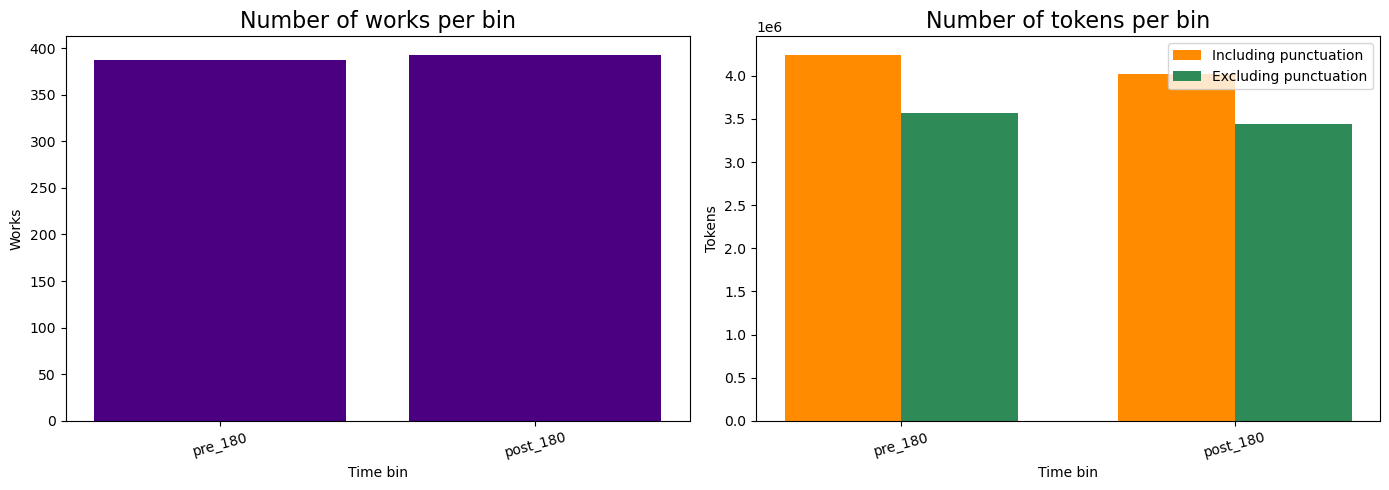

In [22]:
# Plot distibution across the two bins:
works_per_bin = era_counts['works'] if 'works' in era_counts.columns else era_counts.squeeze()
tokens_bin_df = pd.DataFrame()
if 'token_counts_df' in globals() and isinstance(token_counts_df, pd.DataFrame) and not token_counts_df.empty:
    tokens_bin_df = (
        token_counts_df.dropna(subset=['era_bin'])
        .groupby('era_bin')[['tokens_including_punctuation', 'tokens_excluding_punctuation']]
        .sum()
        .sort_index()
    )
elif 'tokens_per_bin' in globals():
    tokens_bin_df = tokens_per_bin.copy()
if isinstance(tokens_bin_df, pd.Series):
    tokens_bin_df = tokens_bin_df.to_frame(name='tokens_excluding_punctuation')
tokens_bin_df = tokens_bin_df.reindex(columns=['tokens_including_punctuation', 'tokens_excluding_punctuation']).fillna(0)

preferred_order = ['pre_180', 'post_180']
ordered_index = [label for label in preferred_order if label in works_per_bin.index]
ordered_index += [label for label in works_per_bin.index if label not in ordered_index]
works_per_bin = works_per_bin.reindex(ordered_index).fillna(0)
tokens_bin_df = tokens_bin_df.reindex(index=ordered_index).fillna(0)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot works per bin
ax[0].bar(works_per_bin.index, works_per_bin.values, color="indigo")
ax[0].set_title("Number of works per bin", fontsize=16)
ax[0].set_xlabel("Time bin")
ax[0].set_ylabel("Works")
ax[0].tick_params(axis='x', rotation=15)

# Plot tokens per bin
ax[1].set_title("Number of tokens per bin", fontsize=16)
ax[1].set_xlabel("Time bin")
ax[1].set_ylabel("Tokens")
if tokens_bin_df.empty or not tokens_bin_df.to_numpy().any():
    ax[1].text(0.5, 0.5, 'No token data', ha='center', va='center')
    ax[1].set_xticks([])
else:
    indices = list(range(len(tokens_bin_df.index)))
    width = 0.35
    ax[1].bar([i - width / 2 for i in indices], tokens_bin_df['tokens_including_punctuation'].values, width, label='Including punctuation', color="darkorange")
    ax[1].bar([i + width / 2 for i in indices], tokens_bin_df['tokens_excluding_punctuation'].values, width, label='Excluding punctuation', color="seagreen")
    ax[1].set_xticks(indices)
    ax[1].set_xticklabels(tokens_bin_df.index, rotation=15)
    ax[1].legend()
plt.tight_layout()
plt.show()

In [23]:
# Identify works with fewer than 50 tokens
min_tokens = 500
short_files = []
missing_token_files = []

punctuation_set = set(punctuation) if 'punctuation' in globals() else set()

for _, row in metadata_ph.iterrows():
    file_path = os.path.join(corpus_dir, row['file'])
    if not os.path.isfile(file_path):
        missing_token_files.append(row['file'])
        continue

    tokens_inc = 0
    tokens_exc = 0
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for raw_line in f:
            tokens = raw_line.strip().split()
            if not tokens:
                continue
            tokens_inc += len(tokens)
            if punctuation_set:
                tokens_exc += sum(token not in punctuation_set for token in tokens)
            else:
                tokens_exc += len(tokens)

    if tokens_inc < min_tokens:
        short_files.append({
            'id': row['id'],
            'file': row['file'],
            'era_bin': row.get('era_bin', ''),
            'tokens_including_punctuation': tokens_inc,
            'tokens_excluding_punctuation': tokens_exc,
        })

short_files_df = pd.DataFrame(short_files).sort_values('tokens_including_punctuation')
print(f"Total works with < {min_tokens} tokens (including punctuation): {len(short_files_df)}")
if not short_files_df.empty:
    display(short_files_df.reset_index(drop=True))

if missing_token_files:
    print("\nWarning: missing files skipped in token counting:")
    for missing_file in missing_token_files:
        print(f"  - {missing_file}")

Total works with < 500 tokens (including punctuation): 250


,id,file,era_bin,tokens_including_punctuation,tokens_excluding_punctuation
0,MQDQ-331,lat_+0040_MQDQ-331.txt,pre_180,3,3
1,MQDQ-341,lat_0044_MQDQ-341.txt,pre_180,4,3
2,MQDQ-568,lat_-0049.0_MQDQ-568.txt,pre_180,4,4
3,MQDQ-348,lat_0550.0_MQDQ-348.txt,post_180,5,5
4,MQDQ-231,lat_-0049.0_MQDQ-231.txt,pre_180,5,5
...,...,...,...,...,...
245,IT-LAT0768,lat_0419_IT-LAT0768.txt,post_180,418,380
246,MQDQ-226,lat_-0234_MQDQ-226.txt,pre_180,419,347
247,MQDQ-123,lat_0250.0_MQDQ-123.txt,post_180,446,369
248,IT-LAT0574,lat_0385_IT-LAT0574.txt,post_180,464,358


In [24]:
# Count lemma frequencies across metadata_ph (excluding punctuation, numeric tokens, and singletons)
show_ordered_preview = True
show_unordered_preview = True
preview_limit = 20

punctuation_set = set(punctuation) if 'punctuation' in globals() else set()
lemma_counts = {}
missing_lemma_files = []

for _, row in metadata_ph.iterrows():
    file_path = os.path.join(corpus_dir, row['file'])
    if not os.path.isfile(file_path):
        missing_lemma_files.append(row['file'])
        continue

    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for raw_line in f:
            tokens = raw_line.strip().split()
            if not tokens:
                continue
            for token in tokens:
                token_norm = token.lower()
                if not token_norm or token_norm in punctuation_set or token_norm.isdigit():
                    continue
                lemma_counts[token_norm] = lemma_counts.get(token_norm, 0) + 1

lemma_counts = {lemma: count for lemma, count in lemma_counts.items() if count > 1}
unique_lemmas = len(lemma_counts)
print(f"Unique lemmas occurring more than once (excluding punctuation/numerical tokens): {unique_lemmas:,}")

lemma_counts_df = pd.DataFrame(list(lemma_counts.items()), columns=['lemma', 'count'])

if show_unordered_preview and not lemma_counts_df.empty:
    print(f"\nUnordered preview (first {preview_limit} rows as read):")
    display(lemma_counts_df.head(preview_limit))

lemma_counts_sorted_df = pd.DataFrame(columns=['lemma', 'count'])
if show_ordered_preview and not lemma_counts_df.empty:
    lemma_counts_sorted_df = lemma_counts_df.sort_values('count', ascending=False).reset_index(drop=True)
    print(f"\nSorted by frequency (top {preview_limit} rows):")
    display(lemma_counts_sorted_df.head(preview_limit))

if missing_lemma_files:
    print("\nWarning: missing files skipped while counting lemmas:")
    for missing_file in missing_lemma_files:
        print(f"  - {missing_file}")

Unique lemmas occurring more than once (excluding punctuation/numerical tokens): 51,690

Unordered preview (first 20 rows as read):


,lemma,count
0,diuus,1326
1,emo,1055
2,cano,1342
3,deus,19980
4,supplico,254
5,cuma,4
6,tono,525
7,prae,528
8,quot,761
9,ibo,2



Sorted by frequency (top 20 rows):


,lemma,count
0,et,231303
1,sum,207551
2,qui,180534
3,in,138032
4,que,102291
5,is,93431
6,hic,75320
7,non,74355
8,ut,59260
9,cum,57712


## Define Christian vs non-Christian subcorpora

### Christian subcorpus

Define set of Christian texts based on Rehan et al. scores:

In [26]:
selected_texts_youden = ['MQDQ-310', 'MQDQ-67', 'MQDQ-458', 'MQDQ-174', 'MQDQ-6', 'MQDQ-133', 'MQDQ-541', 'MQDQ-135', 'MQDQ-222', 'MQDQ-252', 'MQDQ-251', 'MQDQ-187', 'IT-LAT0109', 'MQDQ-448', 'IT-LAT0563', 'MQDQ-446', 'IT-LAT0054', 'IT-LAT0534', 'IT-LAT0044', 'IT-LAT0043', 'IT-LAT0360', 'IT-LAT0062', 'IT-LAT0246', 'IT-LAT0448', 'IT-LAT0737', 'IT-LAT0058', 'IT-LAT0248', 'IT-LAT0934', 'IT-LAT0749', 'IT-LAT0256', 'IT-LAT0350', 'IT-LAT0750', 'IT-LAT0606', 'IT-LAT0733', 'IT-LAT0744', 'IT-LAT0736', 'IT-LAT0747', 'IT-LAT0755', 'IT-LAT0788', 'IT-LAT0471', 'IT-LAT0746', 'LC-1', 'IT-LAT0267', 'IT-LAT0865', 'IT-LAT0059', 'MQDQ-41', 'MQDQ-39', 'MQDQ-40', 'IT-LAT0264', 'IT-LAT0268', 'MQDQ-1', 'IT-LAT0665', 'MQDQ-151', 'MQDQ-241', 'LC-11', 'MQDQ-350', 'MQDQ-617', 'MQDQ-581', 'MQDQ-579', 'IT-LAT0878', 'MQDQ-56', 'IT-LAT0719', 'IT-LAT0263', 'IT-LAT0793', 'IT-LAT0121', 'IT-LAT0397', 'MQDQ-603', 'MQDQ-512', 'MQDQ-165', 'MQDQ-281', 'IT-LAT0410', 'MQDQ-180', 'IT-LAT0847', 'IT-LAT0843', 'IT-LAT0726', 'IT-LAT0403', 'MQDQ-492', 'IT-LAT1004', 'IT-LAT0015', 'MQDQ-26', 'MQDQ-116', 'IT-LAT0612', 'MQDQ-282', 'MQDQ-368', 'MQDQ-367', 'MQDQ-371', 'MQDQ-374', 'MQDQ-375', 'MQDQ-369', 'MQDQ-373', 'MQDQ-366', 'MQDQ-372', 'IT-LAT0270', 'MQDQ-280', 'MQDQ-279', 'IT-LAT0001', 'MQDQ-278', 'MQDQ-365', 'IT-LAT0880', 'MQDQ-52', 'MQDQ-49', 'MQDQ-55', 'MQDQ-48', 'MQDQ-53', 'MQDQ-54', 'MQDQ-50', 'MQDQ-51', 'MQDQ-243', 'MQDQ-242', 'MQDQ-381', 'MQDQ-380', 'IT-LAT0016', 'MQDQ-516', 'IT-LAT0768', 'IT-LAT0608', 'MQDQ-361', 'MQDQ-189', 'MQDQ-422', 'MQDQ-364', 'IT-LAT0904', 'IT-LAT0383', 'MQDQ-66', 'LC-16', 'MQDQ-423', 'MQDQ-218', 'IT-LAT0610', 'MQDQ-363', 'LC-16_1', 'IT-LAT0776', 'MQDQ-444', 'MQDQ-285', 'MQDQ-608', 'MQDQ-445', 'MQDQ-120', 'MQDQ-118', 'MQDQ-59', 'MQDQ-60', 'IT-LAT0251', 'MQDQ-382', 'MQDQ-615', 'MQDQ-287', 'MQDQ-286', 'MQDQ-98', 'MQDQ-383', 'MQDQ-111', 'MQDQ-63', 'MQDQ-75', 'MQDQ-76', 'MQDQ-79', 'MQDQ-81', 'MQDQ-623', 'MQDQ-622', 'MQDQ-627', 'MQDQ-415', 'MQDQ-416', 'MQDQ-618', 'IT-LAT0202', 'IT-LAT0791', 'IT-LAT0867', 'IT-LAT0250', 'MQDQ-353', 'MQDQ-621', 'MQDQ-183', 'IT-LAT1001', 'MQDQ-42', 'MQDQ-354', 'MQDQ-352', 'IT-LAT0196', 'IT-LAT0906', 'IT-LAT0990_6', 'MQDQ-537', 'MQDQ-209', 'IT-LAT0482', 'IT-LAT0990', 'MQDQ-44', 'IT-LAT0990_1', 'IT-LAT0990_9', 'IT-LAT0990_2', 'IT-LAT0011', 'MQDQ-523', 'MQDQ-524', 'MQDQ-525', 'MQDQ-526', 'MQDQ-527', 'MQDQ-528', 'MQDQ-529', 'MQDQ-530', 'IT-LAT0990_4', 'IT-LAT0990_5', 'IT-LAT0990_7', 'MQDQ-211', 'IT-LAT0435', 'MQDQ-531', 'MQDQ-532', 'IT-LAT0783', 'MQDQ-619', 'MQDQ-110', 'MQDQ-119', 'MQDQ-159', 'IT-LAT0978', 'MQDQ-182', 'MQDQ-95', 'MQDQ-475', 'MQDQ-191', 'MQDQ-535', 'MQDQ-536', 'MQDQ-533', 'MQDQ-534']

selected_texts_f1 = ['MQDQ-458', 'MQDQ-6', 'MQDQ-448', 'IT-LAT0044', 'IT-LAT0043', 'IT-LAT0360', 'IT-LAT0062', 'IT-LAT0246', 'IT-LAT0448', 'IT-LAT0737', 'IT-LAT0058', 'IT-LAT0248', 'IT-LAT0749', 'IT-LAT0256', 'IT-LAT0350', 'IT-LAT0750', 'IT-LAT0606', 'IT-LAT0733', 'IT-LAT0744', 'IT-LAT0736', 'IT-LAT0747', 'IT-LAT0755', 'IT-LAT0788', 'IT-LAT0471', 'IT-LAT0746', 'IT-LAT0267', 'IT-LAT0865', 'IT-LAT0059', 'MQDQ-41', 'MQDQ-39', 'MQDQ-40', 'IT-LAT0264', 'IT-LAT0268', 'MQDQ-1', 'MQDQ-151', 'MQDQ-241', 'MQDQ-350', 'MQDQ-617', 'MQDQ-581', 'MQDQ-579', 'IT-LAT0878', 'MQDQ-56', 'IT-LAT0719', 'IT-LAT0263', 'IT-LAT0793', 'IT-LAT0121', 'IT-LAT0397', 'MQDQ-512', 'MQDQ-281', 'IT-LAT0410', 'MQDQ-180', 'IT-LAT0847', 'IT-LAT0843', 'IT-LAT0726', 'IT-LAT0403', 'MQDQ-492', 'IT-LAT1004', 'IT-LAT0015', 'MQDQ-26', 'MQDQ-116', 'IT-LAT0612', 'MQDQ-282', 'MQDQ-368', 'MQDQ-367', 'MQDQ-371', 'MQDQ-374', 'MQDQ-375', 'MQDQ-369', 'MQDQ-373', 'MQDQ-366', 'MQDQ-372', 'IT-LAT0270', 'MQDQ-280', 'MQDQ-279', 'IT-LAT0001', 'MQDQ-278', 'MQDQ-365', 'IT-LAT0880', 'MQDQ-52', 'MQDQ-49', 'MQDQ-55', 'MQDQ-48', 'MQDQ-53', 'MQDQ-54', 'MQDQ-50', 'MQDQ-51', 'MQDQ-243', 'MQDQ-242', 'MQDQ-381', 'IT-LAT0016', 'MQDQ-516', 'IT-LAT0608', 'MQDQ-361', 'MQDQ-189', 'MQDQ-422', 'IT-LAT0904', 'IT-LAT0383', 'MQDQ-66', 'LC-16', 'MQDQ-423', 'IT-LAT0610', 'MQDQ-363', 'LC-16_1', 'IT-LAT0776', 'MQDQ-444', 'MQDQ-285', 'MQDQ-608', 'MQDQ-120', 'MQDQ-118', 'MQDQ-59', 'MQDQ-60', 'IT-LAT0251', 'MQDQ-382', 'MQDQ-287', 'MQDQ-286', 'MQDQ-383', 'MQDQ-111', 'MQDQ-75', 'MQDQ-76', 'MQDQ-79', 'MQDQ-623', 'MQDQ-622', 'MQDQ-415', 'MQDQ-416', 'MQDQ-618', 'IT-LAT0791', 'IT-LAT0867', 'IT-LAT0250', 'MQDQ-353', 'MQDQ-183', 'IT-LAT1001', 'MQDQ-354', 'MQDQ-352', 'IT-LAT0906', 'IT-LAT0990_6', 'MQDQ-537', 'MQDQ-209', 'IT-LAT0482', 'IT-LAT0990', 'MQDQ-44', 'IT-LAT0990_1', 'IT-LAT0990_9', 'IT-LAT0990_2', 'IT-LAT0011', 'MQDQ-523', 'MQDQ-524', 'MQDQ-525', 'MQDQ-526', 'MQDQ-527', 'MQDQ-528', 'MQDQ-529', 'MQDQ-530', 'IT-LAT0990_4', 'IT-LAT0990_5', 'IT-LAT0990_7', 'MQDQ-211', 'IT-LAT0435', 'MQDQ-531', 'MQDQ-532', 'IT-LAT0783', 'MQDQ-619', 'MQDQ-110', 'MQDQ-159', 'IT-LAT0978', 'MQDQ-182', 'MQDQ-95', 'MQDQ-475', 'MQDQ-191', 'MQDQ-535', 'MQDQ-536', 'MQDQ-533', 'MQDQ-534']

Display selection metadata:

In [33]:
metadata_ph_christian = metadata_ph[(metadata_ph['era_bin']=='post_180') & (metadata_ph['id'].isin(selected_texts_youden))].copy()
# metadata_ph_christian.to_csv(os.path.join(dir_out, 'metadata_christian.csv'), index=None)
metadata_ph_christian

,id,title,creator,date_avg,date_range_start,date_range_end,type,file,era_bin,century
388,IT-LAT0044,Acta martyrum scillitanorum,[Auctor incertus],180,180,180,prose,lat_0180_IT-LAT0044.txt,post_180,2
390,IT-LAT0043,Metamorphoses,"Apuleius, Lucius",170,150,190,prose,lat_0158_IT-LAT0043.txt,post_180,2
391,IT-LAT0360,Noctes Atticae,"Gellius, Aulus",175,160,190,prose,lat_0150_IT-LAT0360.txt,post_180,2
392,IT-LAT0062,Ad martyres,"Tertullianus, Quintus Septimius Florens",197,196,197,prose,lat_0197_IT-LAT0062.txt,post_180,2
393,IT-LAT0246,Apologeticum,"Tertullianus, Quintus Septimius Florens",197,196,197,prose,lat_0197_IT-LAT0246.txt,post_180,2
...,...,...,...,...,...,...,...,...,...,...
774,MQDQ-191,in Euangelia,Severus Malacitanus,576,550,602,poetry,lat_0550.0_MQDQ-191.txt,post_180,7
776,MQDQ-535,carminum appendix,Venantius Fortunatus,587,570,605,poetry,lat_0601_MQDQ-535.txt,post_180,7
777,MQDQ-536,spuriorum appendix,Venantius Fortunatus,587,570,605,poetry,lat_0601_MQDQ-536.txt,post_180,7
778,MQDQ-533,carminum libri 10,Venantius Fortunatus,597,590,605,poetry,lat_0601_MQDQ-533.txt,post_180,7


Double check date is reasonable:

In [29]:
metadata_ph_christian['era_bin'].max()

'pre_180'

### Non-Christian control subcorpus (post 180 CE)

Select post 180 CE non-Christian texts by exclusion and display metadata:

In [34]:
metadata_ph_nonchristian = metadata_ph[(metadata_ph['era_bin']=='post_180') & (~metadata_ph['id'].isin(selected_texts_youden))].copy()
metadata_ph_nonchristian

,id,title,creator,date_avg,date_range_start,date_range_end,type,file,era_bin,century
387,MQDQ-213,fragmentum,Marullus,170,161,180,poetry,lat_0050.0_MQDQ-213.txt,post_180,2
389,MQDQ-335,carminum fragmenta,"Apuleius, Lucius",170,150,190,poetry,lat_0147_MQDQ-335.txt,post_180,2
398,MQDQ-345,carmina Priapea,[Auctor incertus],87,-27,200,poetry,lat_0150.0_MQDQ-345.txt,post_180,2
399,IT-LAT0051,Fabulae,"Hyginus, Gaius Iulius",88,-25,200,prose,lat_0050_IT-LAT0051.txt,post_180,2
400,IT-LAT0355,De astronomia,"Hyginus, Gaius Iulius",88,-25,200,prose,lat_0050_IT-LAT0355.txt,post_180,2
...,...,...,...,...,...,...,...,...,...,...
756,IT-LAT0433,Pro repellenda iactantia,Martinus Bracarensis,564,550,579,prose,lat_0550_IT-LAT0433.txt,post_180,6
760,IT-LAT0990_8,"Formula vitae honestae, De quattuor virtutibus",Martinus Bracarensis,574,570,579,prose,lat_0550_IT-LAT0990_8.txt,post_180,6
770,MQDQ-216,elegiarum appendix,Maximianus,550,500,600,poetry,lat_0550.0_MQDQ-216.txt,post_180,6
771,MQDQ-215,elegiae,Maximianus,550,500,600,poetry,lat_0550.0_MQDQ-215.txt,post_180,6


In [79]:
nonchristian_selected_texts = list(metadata_ph_nonchristian['id'])
nonchristian_selected_texts

['MQDQ-213',
 'IT-LAT0044',
 'MQDQ-335',
 'IT-LAT0043',
 'IT-LAT0360',
 'IT-LAT0448',
 'IT-LAT0248',
 'MQDQ-345',
 'IT-LAT0051',
 'IT-LAT0355',
 'IT-LAT0784',
 'IT-LAT0348',
 'MQDQ-436',
 'MQDQ-394',
 'MQDQ-395',
 'MQDQ-396',
 'MQDQ-397',
 'MQDQ-398',
 'MQDQ-399',
 'MQDQ-400',
 'MQDQ-401',
 'MQDQ-402',
 'MQDQ-403',
 'MQDQ-404',
 'MQDQ-405',
 'MQDQ-408',
 'MQDQ-409',
 'MQDQ-410',
 'MQDQ-411',
 'MQDQ-412',
 'IT-LAT0934',
 'IT-LAT0916',
 'MQDQ-490',
 'MQDQ-240',
 'MQDQ-138',
 'IT-LAT0733',
 'MQDQ-491',
 'IT-LAT0347',
 'LC-1',
 'MQDQ-152',
 'IT-LAT0201',
 'IT-LAT0267',
 'IT-LAT0893',
 'IT-LAT0895',
 'IT-LAT0896',
 'MQDQ-439',
 'IT-LAT0846',
 'MQDQ-232',
 'MQDQ-233',
 'MQDQ-377',
 'MQDQ-558',
 'IT-LAT0204',
 'IT-LAT0913',
 'IT-LAT0914',
 'MQDQ-107',
 'IT-LAT0621',
 'MQDQ-234',
 'MQDQ-157',
 'MQDQ-289',
 'MQDQ-158',
 'IT-LAT0665',
 'MQDQ-499',
 'MQDQ-500',
 'MQDQ-241',
 'IT-LAT0886',
 'LC-11',
 'MQDQ-166',
 'MQDQ-540',
 'MQDQ-580',
 'IT-LAT0233',
 'MQDQ-569',
 'MQDQ-570',
 'MQDQ-571',
 'MQDQ

### Count texts and tokens

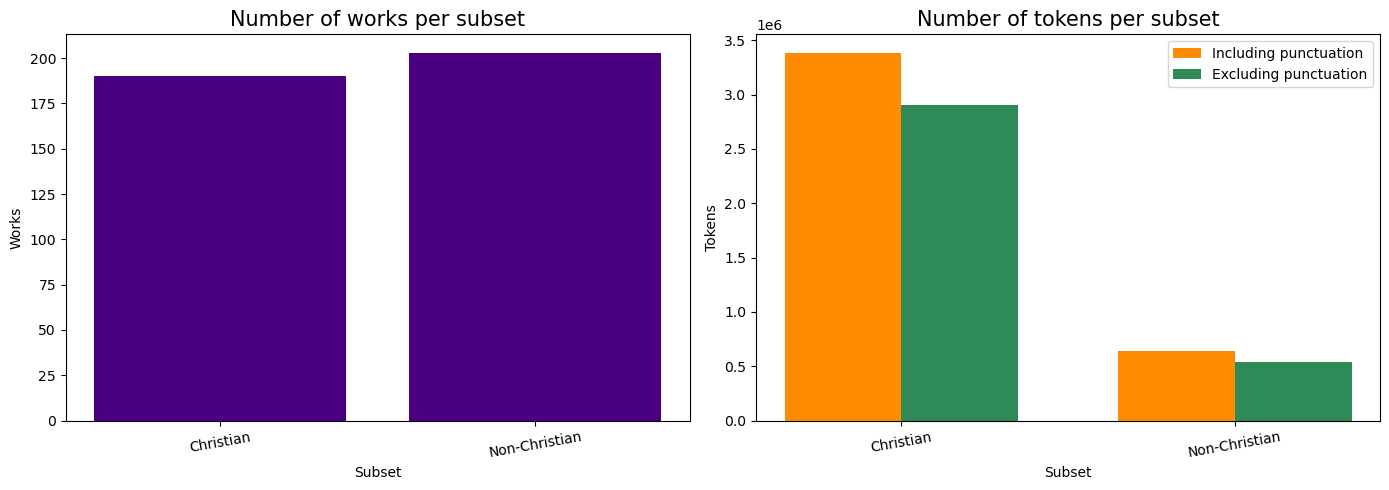

,works,tokens_including_punctuation,tokens_excluding_punctuation
label,,,
Christian,190,3386164,2901607
Non-Christian,203,639250,535503


In [35]:
# Count works/tokens for Christian vs non-Christian subsets
punctuation_set = set(punctuation) if 'punctuation' in globals() else set()


def summarize_subset(subset_df: pd.DataFrame, label: str) -> dict:
    stats = {
        "label": label,
        "works": int(subset_df['file'].nunique()) if not subset_df.empty else 0,
        "tokens_including_punctuation": 0,
        "tokens_excluding_punctuation": 0,
        "missing_files": [],
    }

    if subset_df.empty:
        return stats

    for _, row in subset_df.iterrows():
        file_path = os.path.join(corpus_dir, row['file'])
        if not os.path.isfile(file_path):
            stats["missing_files"].append(row['file'])
            continue

        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for raw_line in f:
                tokens = raw_line.strip().split()
                if not tokens:
                    continue
                stats["tokens_including_punctuation"] += len(tokens)
                if punctuation_set:
                    stats["tokens_excluding_punctuation"] += sum(token not in punctuation_set for token in tokens)
                else:
                    stats["tokens_excluding_punctuation"] += len(tokens)

    return stats

subset_stats = [
    summarize_subset(metadata_ph_christian, "Christian"),
    summarize_subset(metadata_ph_nonchristian, "Non-Christian"),
]

subset_stats_df = (
    pd.DataFrame([{k: v for k, v in stats.items() if k != "missing_files"} for stats in subset_stats])
    .set_index("label")
    .sort_index()
)

missing_info = [stats for stats in subset_stats if stats["missing_files"]]
if missing_info:
    print("Warning: some files were missing and skipped during counting:")
    for stats in missing_info:
        print(f"  - {stats['label']}: {stats['missing_files']}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Works per subset
ax[0].bar(subset_stats_df.index, subset_stats_df['works'], color='indigo')
ax[0].set_title('Number of works per subset', fontsize=15)
ax[0].set_xlabel('Subset')
ax[0].set_ylabel('Works')
ax[0].tick_params(axis='x', rotation=10)

# Tokens per subset (with/without punctuation)
indices = np.arange(len(subset_stats_df))
width = 0.35
ax[1].bar(indices - width / 2, subset_stats_df['tokens_including_punctuation'], width,
          label='Including punctuation', color='darkorange')
ax[1].bar(indices + width / 2, subset_stats_df['tokens_excluding_punctuation'], width,
          label='Excluding punctuation', color='seagreen')
ax[1].set_title('Number of tokens per subset', fontsize=15)
ax[1].set_xlabel('Subset')
ax[1].set_ylabel('Tokens')
ax[1].set_xticks(indices)
ax[1].set_xticklabels(subset_stats_df.index, rotation=10)
ax[1].legend()

plt.tight_layout()
plt.show()

subset_stats_df

In [36]:
metadata_ph_christian_untimed = metadata_ph[(metadata_ph['id'].isin(selected_texts_youden))]
metadata_ph_nonchristian_untimed = metadata_ph[(~metadata_ph['id'].isin(selected_texts_youden))]

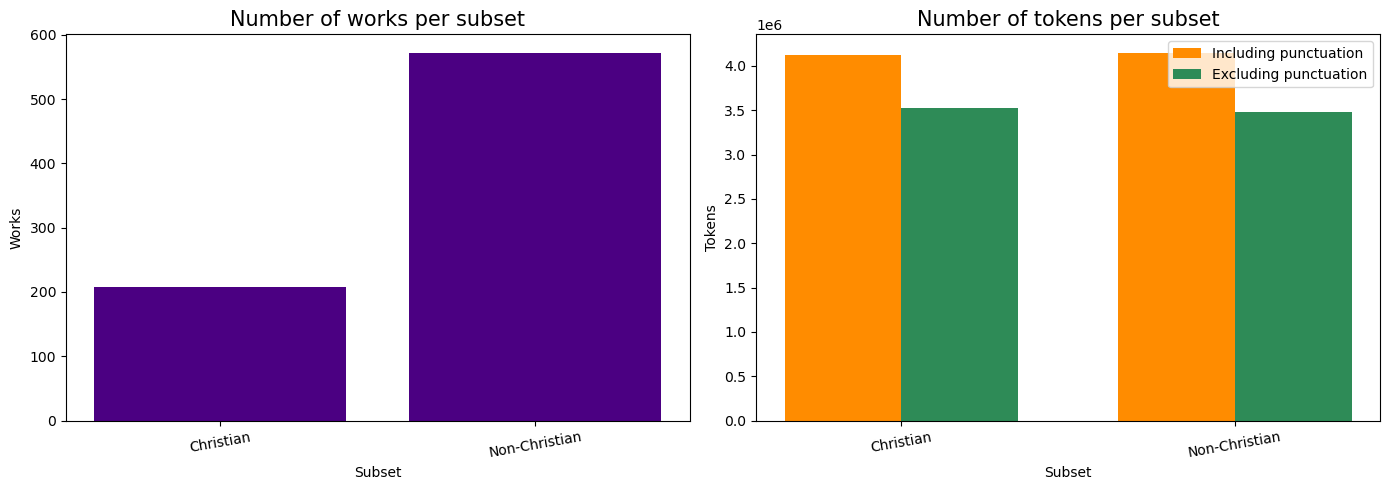

,works,tokens_including_punctuation,tokens_excluding_punctuation
label,,,
Christian,208,4122639,3530657
Non-Christian,572,4148794,3475783


In [37]:
subset_stats = [
    summarize_subset(metadata_ph_christian_untimed, "Christian"),
    summarize_subset(metadata_ph_nonchristian_untimed, "Non-Christian"),
]

subset_stats_df = (
    pd.DataFrame([{k: v for k, v in stats.items() if k != "missing_files"} for stats in subset_stats])
    .set_index("label")
    .sort_index()
)

missing_info = [stats for stats in subset_stats if stats["missing_files"]]
if missing_info:
    print("Warning: some files were missing and skipped during counting:")
    for stats in missing_info:
        print(f"  - {stats['label']}: {stats['missing_files']}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Works per subset
ax[0].bar(subset_stats_df.index, subset_stats_df['works'], color='indigo')
ax[0].set_title('Number of works per subset', fontsize=15)
ax[0].set_xlabel('Subset')
ax[0].set_ylabel('Works')
ax[0].tick_params(axis='x', rotation=10)

# Tokens per subset (with/without punctuation)
indices = np.arange(len(subset_stats_df))
width = 0.35
ax[1].bar(indices - width / 2, subset_stats_df['tokens_including_punctuation'], width,
          label='Including punctuation', color='darkorange')
ax[1].bar(indices + width / 2, subset_stats_df['tokens_excluding_punctuation'], width,
          label='Excluding punctuation', color='seagreen')
ax[1].set_title('Number of tokens per subset', fontsize=15)
ax[1].set_xlabel('Subset')
ax[1].set_ylabel('Tokens')
ax[1].set_xticks(indices)
ax[1].set_xticklabels(subset_stats_df.index, rotation=10)
ax[1].legend()

plt.tight_layout()
plt.show()

subset_stats_df

## Train embeddings for whole corpus

Function for printing the vocabulary of a model:

In [19]:
def print_vocab(model, top_n = None):
  if model == '':
    print("Empty model!")
  else:
    count = 0
    if top_n is not None:
      for index, word in enumerate(model.wv.index_to_key):
        count+= 1
        if count < top_n:
          print(f"word #{index}/{len(model.wv.index_to_key)} is {word}")
    else:
      for index, word in enumerate(model.wv.index_to_key):
        print(f"word #{index}/{len(model.wv.index_to_key)} is {word}")

### Make corpus

Create a list of lists, containing the (lemmatized) tokens of each sentence in the whole corpus (excluding punctuation):

In [21]:
def normalize_text_fragment(text: str) -> str:
    """Normalize whitespace and map v/V to u/U for consistent tokenization."""
    if not text:
        return ""
    normalized = text.replace('\r', ' ').replace('\n', ' ')
    normalized = normalized.replace('v', 'u').replace('V', 'U')
    return ' '.join(normalized.split())

In [22]:
corpus = []
for idx, row in metadata_ph.iterrows():
    file_name = row['file']
    file_path = os.path.join(corpus_dir, file_name)
    try:
        with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
            for line in f:
                clean_line = normalize_text_fragment(line)
                if clean_line:
                    tokens = [token for token in clean_line.split() if token not in punctuation]
                    if tokens:
                        corpus.append(tokens)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

Show the corpus:

In [23]:
corpus

[['diuus',
  'emo',
  'cano',
  'diuus',
  'deus',
  'supplico',
  'cuma',
  'tono',
  'Leucesia',
  'prae',
  'tet',
  'tremoo',
  'quot',
  'ibo',
  'etinei',
  'de',
  'hic',
  'cum',
  'tono',
  'coazeulodorieso'],
 ['omnis', 'uero', 'adpatula', 'coemitto'],
 ['si', 'in', 'ius', 'uoco', 'eo'],
 ['ni', 'eo', 'antestamino'],
 ['igitur', 'es', 'capitus'],
 ['si', 'caluor', 'pes', 'ue', 'struo', 'manus', 'o', 'iacio'],
 ['si', 'morbus', 'aeuitasue', 'uitium', 'esco', 'iumentum', 'do'],
 ['si', 'nolo', 'arcer', 'ne', 'sterno'],
 ['assiduo', 'uindex', 'assiduus', 'sum'],
 ['proletarius', 'iam', 'ciuis', 'quis', 'uolo', 'uindex', 'sum'],
 ['nex', '...', 'fortis', 'sano', '...', 'res', 'ubi', 'paco', 'oro'],
 ['ni',
  'paco',
  'in',
  'comitio',
  'aut',
  'in',
  'forum',
  'ante',
  'meridies',
  'caussa',
  'coicio'],
 ['cum', 'peroro', 'ambo', 'praesens'],
 ['post', 'meridies', 'praesens', 'lis', 'addico'],
 ['si',
  'ambo',
  'praesens',
  'solus',
  'occasus',
  'supremus',
  'tempe

Count how many sentences in corpus:

In [24]:
len(corpus)

420799

And how many words:

In [25]:
# Number of words
num_words = sum(len(i) for i in corpus)
num_words

7006440

### Train with FastText and play with parameters

Function for training FastText models (from Krzysztof Nowak):

In [26]:
def fasttext(self, opts=dict()):
        """
        Reads sentences from the corpus. Implements:
            https://radimrehurek.com/gensim/models/fasttext.html#gensim.models.fasttext.FastText
        Returns
        -------
        FastText model
        """
        default_opts = dict(vector_size=100, alpha=0.025,
                            window=5, min_count=5, epochs=5)
        opts_new = default_opts
        for opt in opts.keys():
            opts_new[opt] = opts[opt]
        model = FastText(
            vector_size=opts_new["vector_size"],
            alpha=opts_new["alpha"],
            window=opts_new["window"],
            min_count=opts_new["min_count"])
        model.build_vocab(corpus_iterable=[sentence for sentence in
                                           self.corpus.get_sents()])
        total_examples = model.corpus_count
        model.train(corpus_iterable=[sentence for sentence
                                     in self.corpus.get_sents()],
                    total_examples=total_examples,
                    epochs=opts_new["epochs"])
        return model

Parameters:

`min_count`: the minimum frequency threshold allowed for a word to be included; set to 3 following Ribary & McGillivray (2020) or 5 following Sprugnoli et al. (2019).

`vector_size`: the number of dimensions in which we wish to represent our word. This is the size of the word embedding; typically between 100 and 1,000. Set to 100 following Ribary & McGillivray (2020).

`window`: The size of the context window determines how many words before and after a given word would be included as context words of the given word. Typically between 5 and 10. Set to 10 following Sprugnoli et al. (2020).

`sg`: – Training algorithm: 1 for skip-gram; otherwise CBOW.

Train FastText embeddings and, for full reproducibility, limit the model to a single worker thread (workers=1), to eliminate ordering jitter from OS thread scheduling:

In [27]:
model = FastText(vector_size=100, alpha=0.025, window=1, min_count=50, workers=1, seed=1, hashfxn=hash)
model.build_vocab(corpus_iterable=corpus)
model.train(corpus_iterable=corpus, total_examples=model.corpus_count, epochs=5)

(27004387, 35032200)

Let's see what words are similar to "deus":

In [28]:
model.wv.similar_by_word('deus', 10)

[('Tydeus', 0.8390597105026245),
 ('Deus', 0.8095588684082031),
 ('spondeus', 0.6703999638557434),
 ('lapideus', 0.6672897934913635),
 ('peus', 0.6607303619384766),
 ('Heus', 0.6555080413818359),
 ('heus', 0.6327313780784607),
 ('Prometheus', 0.6288886666297913),
 ('chaldaeus', 0.6243531703948975),
 ('dea', 0.6125942468643188)]

Let's try with different parameters:

In [ ]:
start = time.time()
model = FastText(vector_size=100, window=5, min_count=5, workers=1, seed=1, hashfxn=hash)
model.build_vocab(corpus_iterable=corpus)
model.train(corpus_iterable=corpus, total_examples=model.corpus_count, epochs=3)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 131 seconds


[('Tydeus', 0.8640301823616028),
 ('sotadeus', 0.8530239462852478),
 ('Deus', 0.8277772068977356),
 ('chaldeus', 0.8274319171905518),
 ('Phocideus', 0.8254609704017639),
 ('Chaldeus', 0.7838060259819031),
 ('semideus', 0.7743955850601196),
 ('Nicomedeus', 0.7500133514404297),
 ('lapideus', 0.7215065360069275),
 ('deunx', 0.6981386542320251)]

In [50]:
start = time.time()
model = FastText(vector_size=100, window=10, min_count=5, workers=1, seed=1, hashfxn=hash)
model.build_vocab(corpus_iterable=corpus)
model.train(corpus_iterable=corpus, total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 196 seconds


[('Tydeus', 0.8693391680717468),
 ('sotadeus', 0.8388153314590454),
 ('Deus', 0.8329287171363831),
 ('chaldeus', 0.8262607455253601),
 ('Phocideus', 0.8172575235366821),
 ('Chaldeus', 0.7941907048225403),
 ('semideus', 0.7702943682670593),
 ('Nicomedeus', 0.7378280758857727),
 ('lapideus', 0.7288469076156616),
 ('numen', 0.7040475010871887)]

The model has a vocabulary of

In [29]:
model.corpus_total_words

7006440

words and

In [30]:
model.corpus_count

420799

sentences.

Different configurations of the parameters for the embeddings against the gold standard set by Sprugnoli et al. (2019) (https://github.com/CIRCSE/Lemma-Embeddings-for-Latin/blob/master/syn-selection-benchmark-Latin.tsv) are evaluated to find the best configuration of parameters here: https://gitlab.surrey.ac.uk/mr0048/pydigest/-/blob/master/script/fasttext_003.py

### Train with Word2Vec and play with parameters

FastText captures subword information, but it is useful to benchmark a classic Word2Vec model on the same normalized `corpus`. We will start with a skip-gram configuration (`sg=1`) and keep `workers=1` for reproducibility so the results are comparable with the FastText runs above.

In [ ]:
def train_word2vec(corpus_iterable, opts=None):
    """Train a Word2Vec model on the normalized corpus."""
    if not corpus_iterable:
        raise ValueError("Corpus is empty. Re-run the corpus-building cell before training Word2Vec.")

    default_opts = {
        "vector_size": 100,
        "window": 5,
        "min_count": 5,
        "sg": 0,  # 1=skip-gram, 0=CBOW
        "negative": 10,
        "workers": 1,
        "seed": 1,
        "epochs": 5,
    }
    if opts:
        default_opts.update(opts)

    model = Word2Vec(
        vector_size=default_opts["vector_size"],
        window=default_opts["window"],
        min_count=default_opts["min_count"],
        sg=default_opts["sg"],
        negative=default_opts["negative"],
        workers=default_opts["workers"],
        seed=default_opts["seed"],
    )

    start = time.time()
    model.build_vocab(corpus_iterable=corpus_iterable)
    model.train(
        corpus_iterable=corpus_iterable,
        total_examples=model.corpus_count,
        epochs=default_opts["epochs"],
    )
    duration = time.time() - start
    return model, duration

word2vec_params = {
    "vector_size": 100,
    "window": 5,
    "min_count": 20,
    "sg": 0,  # CBOW
    "negative": 10,
    "workers": 1,
    "seed": 1,
    "epochs": 5,
}

word2vec_model, duration = train_word2vec(corpus, word2vec_params)
print(
    f"Word2Vec trained on {word2vec_model.corpus_count} sentences in {duration:.1f} seconds"
)
word2vec_model.wv.similar_by_word("deus", topn=10)

Word2Vec trained on 420799 sentences in 41.2 seconds


[('dus', 0.793084979057312),
 ('dium', 0.7305129170417786),
 ('Deus', 0.6913812756538391),
 ('numen', 0.690052330493927),
 ('dea', 0.6224372386932373),
 ('caelitus', 0.6182945370674133),
 ('caelestis', 0.6084222197532654),
 ('creator', 0.5928256511688232),
 ('ueneratio', 0.5876426696777344),
 ('superus', 0.5836797952651978)]

In [100]:
word2vec_params = {
    "vector_size": 100,
    "window": 10,
    "min_count": 20,
    "sg": 1,  # Skip-gram
    "negative": 10,
    "workers": 1,
    "seed": 1,
    "epochs": 3,
}

word2vec_model, duration = train_word2vec(corpus, word2vec_params)
print(
    f"Word2Vec trained on {word2vec_model.corpus_count} sentences in {duration:.1f} seconds"
)
word2vec_model.wv.similar_by_word("deus", topn=10)

Word2Vec trained on 420799 sentences in 145.2 seconds


[('numen', 0.7949856519699097),
 ('caelitus', 0.7930249571800232),
 ('creator', 0.7577016949653625),
 ('Deus', 0.7559593319892883),
 ('Sapientia', 0.7558107376098633),
 ('omnipotens', 0.7423361539840698),
 ('fabricator', 0.7370187044143677),
 ('sator', 0.733025074005127),
 ('Fides', 0.7280563116073608),
 ('factor', 0.7249476909637451)]

## Train embeddings for each time interval

### Make corpora for chronological bins

For each chronological bin (`era_bin`), read the normalized texts and create a list of tokenized sentences (excluding punctuation) so we can train bin-specific embeddings.

In [35]:
def build_corpus_from_rows(rows, missing_files):
    sentences = []
    for _, row in rows.iterrows():
        file_name = row['file']
        file_path = os.path.join(corpus_dir, file_name)
        try:
            with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
                for line in f:
                    clean_line = normalize_text_fragment(line)
                    if clean_line:
                        tokens = [token for token in clean_line.split() if token not in punctuation]
                        if tokens:
                            sentences.append(tokens)
        except FileNotFoundError:
            missing_files.append(file_name)
        except Exception as exc:
            print(f"Error reading {file_name}: {exc}")
    return sentences

if 'era_bin' not in metadata_ph.columns:
    raise ValueError("metadata_ph must include an 'era_bin' column to build bin corpora.")

bin_corpora = {}
missing_bin_files = []
metadata_with_bins = metadata_ph.dropna(subset=['era_bin']).copy()

for bin_value, subset in metadata_with_bins.groupby('era_bin', sort=False):
    bin_corpora[bin_value] = build_corpus_from_rows(subset, missing_bin_files)

if missing_bin_files:
    print(f"Skipped {len(missing_bin_files)} files that were not found in {corpus_dir}.")

bin_labels = list(bin_corpora.keys())
bin_labels

['pre_180', 'post_180']

Bin-level corpus summary:

In [36]:
bin_stats_df = pd.DataFrame(columns=['num_sentences', 'num_tokens'])

if not bin_corpora:
    print("bin_corpora is empty. Re-run the corpus-building cell above.")
else:
    bin_stats = []
    for label in bin_labels:
        sentences = bin_corpora[label]
        bin_stats.append(
            {
                'era_bin': label,
                'num_sentences': len(sentences),
                'num_tokens': sum(len(sent) for sent in sentences)
            }
        )
    bin_stats_df = (
        pd.DataFrame(bin_stats)
        .set_index('era_bin')
        .loc[bin_labels]
    )

bin_stats_df

,num_sentences,num_tokens
era_bin,,
pre_180,194612,3569330
post_180,226187,3437110


Token ratio between the first and second bin (based on the order in `bin_labels`):

In [37]:
if bin_stats_df.empty or len(bin_labels) < 2:
    print("Need at least two populated bins to compute a ratio.")
else:
    first_bin, second_bin = bin_labels[:2]
    token_ratio = bin_stats_df.loc[first_bin, 'num_tokens'] / bin_stats_df.loc[second_bin, 'num_tokens']
    print(f"Token ratio {first_bin}/{second_bin}: {token_ratio:.2f}")

Token ratio pre_180/post_180: 1.04


The two bins are reasonably balanced in terms of total tokens.

### Train with FastText and play with parameters

Following the findings of Sprugnoli et al. (2019) and Ribary & McGillivray (2020), train a fasttext model for each time interval:

Train embeddings for the first time interval:

In [ ]:
start = time.time()
#model = gensim.models.Word2Vec(bin_corpora['pre_180'], min_count=5, vector_size=100, window = 10, sg = 1)
start = time.time()
model = FastText(vector_size=100, window=5, min_count=5, workers=1, seed=1, hashfxn=hash)
model.build_vocab(corpus_iterable=bin_corpora['pre_180'])
model.train(corpus_iterable=bin_corpora['pre_180'], total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 67 seconds


[('sotadeus', 0.8637253642082214),
 ('Tydeus', 0.8498998880386353),
 ('deunx', 0.8398290276527405),
 ('spondeus', 0.8279481530189514),
 ('semideus', 0.7730532884597778),
 ('dea', 0.755585789680481),
 ('lapideus', 0.7551931142807007),
 ('Iuppiter', 0.7234874963760376),
 ('diuus', 0.6728280186653137),
 ('sacrosanctus', 0.6723106503486633)]

In [ ]:
print_vocab(model, 10)

The corpus is small and the fasttext seems to prefer orthographic similarity with smaller min_counts. We're not interested in deus being similar to lapideus, but rather in deus being similar to divunus or immortalis. So, we have two options: we may either turn off the subwords or apply high frequency threshold (but we're going to lose low-frequency terms).

Try changing the parameters to exclude subwords (set `max_n` to 0):

In [ ]:
start = time.time()
#model = gensim.models.Word2Vec(bin_corpora['pre_180'], min_count=5, vector_size=100, window = 10, sg = 1)
start = time.time()
model = FastText(vector_size=100, window=10, min_count=5, workers=1, seed=1, hashfxn=hash, max_n=0) 
model.build_vocab(corpus_iterable=bin_corpora['pre_180'])
model.train(corpus_iterable=bin_corpora['pre_180'], total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

In [ ]:
model.wv.similar_by_word('dominus', 10)

Additionally, we could set a higher frequency threshold (set `min_count` to 50 rather than 5), but we would lose low-frequency terms:

In [ ]:
start = time.time()
#model = gensim.models.Word2Vec(bin_corpora['pre_180'], min_count=5, vector_size=100, window = 10, sg = 1)
start = time.time()
model = FastText(vector_size=100, window=10, min_count=50, workers=1, seed=1, hashfxn=hash, max_n=0) 
model.build_vocab(corpus_iterable=bin_corpora['pre_180'])
model.train(corpus_iterable=bin_corpora['pre_180'], total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

In [ ]:
model.wv.similar_by_word('dominus', 10)

Train embeddings for all time intervals (however many):

In [ ]:
models = list()
start = time.time()
for t in range(len(time2corpus)):
    if len(time2corpus[t])>0:
        print(t)
        #model = gensim.models.Word2Vec(time2corpus[0][0], min_count=1, vector_size=300, window = 5, sg = 0)
        model = FastText(vector_size=100, window=5, min_count=50, workers=1, seed=1, hashfxn=hash, max_n=0)  # instantiate
        model.build_vocab(corpus_iterable=time2corpus[t])
        model.train(corpus_iterable=time2corpus[t], total_examples=len(time2corpus[t]), epochs=10)  # train
        models.append(model)
        #model = fasttext.train_unsupervised(time2corpus[0][0], model='skipgram')
end = time.time()
print("It has taken", round(end - start), "seconds, or ", round((end - start)/60), "minutes")

Check some models:

In [ ]:
print_vocab(models[0], 20)

In [ ]:
models[0].wv.similar_by_word('deus', 10)

In [ ]:
print_vocab(models[1], 20)

In [ ]:
models[0].wv.get_vecattr('deus', "count")

In [ ]:
models[1].wv.get_vecattr('deus', "count")

In [ ]:
models[1].wv.get_vecattr('panis', "count")

In [ ]:
models[0].wv.get_vecattr('panis', "count")

In [ ]:
models[0].wv.get_vecattr('oratio', "count")

In [ ]:
models[1].wv.get_vecattr('oratio', "count")

In [ ]:
models[1].wv.similar_by_word('deus', 10)

In [ ]:
models[0].wv.similar_by_word('communico', 10)

In [ ]:
models[1].wv.similar_by_word('communico', 10)

In [ ]:
models[0].wv.similar_by_word('communio', 10)

In [ ]:
models[1].wv.similar_by_word('communio', 10)

In [ ]:
models[0].wv.similar_by_word('oratio', 10)

In [ ]:
models[1].wv.similar_by_word('oratio', 10)

In [ ]:
models[0].wv.similar_by_word('memoria', 10)

In [ ]:
models[1].wv.similar_by_word('panis', 10)

In [ ]:
models[0].wv.similar_by_word('panis', 10)

In [ ]:
models[1].wv.similar_by_word('propheta', 10)

In [ ]:
models[0].wv.similar_by_word('desertum', 10)

In [ ]:
models[1].wv.similar_by_word('desertum', 10)

In [ ]:
#models[1].wv.similar_by_word('eremus', 10)

In [ ]:
models[1].wv.similar_by_word('virtus', 10)

In [ ]:
models[0].wv.similar_by_word('virtus', 10)

In [ ]:
models[0].wv.similar_by_word('gratia', 10)

In [ ]:
models[1].wv.similar_by_word('gratia', 10)

In [ ]:
models[0].wv.similar_by_word('lex', 10)

In [ ]:
models[1].wv.similar_by_word('lex', 10)

### Embedding space alignment

Code from https://gist.github.com/zhicongchen/9e23d5c3f1e5b1293b16133485cd17d8, ported from HistWords https://github.com/williamleif/histwords.

Function to find the intersection between the vocabularies of two word2vec models:

In [ ]:
def intersection_align_gensim(m1, m2, words=None):
    """
    Intersect two gensim word2vec models, m1 and m2.
    Only the shared vocabulary between them is kept.
    If 'words' is set (as list or set), then the vocabulary is intersected with this list as well.
    Indices are re-organized from 0..N in order of descending frequency (=sum of counts from both m1 and m2).
    These indices correspond to the new syn0 and syn0norm objects in both gensim models:
        -- so that Row 0 of m1.syn0 will be for the same word as Row 0 of m2.syn0
        -- you can find the index of any word on the .index2word list: model.index2word.index(word) => 2
    The .vocab dictionary is also updated for each model, preserving the count but updating the index.
    """

    # Get the vocab for each model
    vocab_m1 = set(m1.wv.index_to_key)
    vocab_m2 = set(m2.wv.index_to_key)

    # Find the common vocabulary
    common_vocab = vocab_m1 & vocab_m2
    if words: common_vocab &= set(words)

    # If no alignment necessary because vocab is identical...
    if not vocab_m1 - common_vocab and not vocab_m2 - common_vocab:
        return (common_vocab, m1,m2)

    # Otherwise sort by frequency (summed for both)
    common_vocab = list(common_vocab)
    common_vocab.sort(key=lambda w: m1.wv.get_vecattr(w, "count") + m2.wv.get_vecattr(w, "count"), reverse=True)
    # print(len(common_vocab))

    # Then for each model...
    for m in [m1, m2]:
        # Replace old syn0norm array with new one (with common vocab)
        indices = [m.wv.key_to_index[w] for w in common_vocab]
        old_arr = m.wv.vectors
        new_arr = np.array([old_arr[index] for index in indices])
        m.wv.vectors = new_arr

        # Replace old vocab dictionary with new one (with common vocab)
        # and old index2word with new one
        new_key_to_index = {}
        new_index_to_key = []
        for new_index, key in enumerate(common_vocab):
            new_key_to_index[key] = new_index
            new_index_to_key.append(key)
        m.wv.key_to_index = new_key_to_index
        m.wv.index_to_key = new_index_to_key
        
        print(len(m.wv.key_to_index), len(m.wv.vectors))
        
    print(common_vocab)
    print(m1)
    print(m2)
    return (common_vocab, m1, m2)

Function for aligning two spaces with Orthogonal Procrustes:

In [ ]:
def smart_procrustes_align_gensim(base_embed, other_embed, words=None):
    """
    Original script: https://gist.github.com/quadrismegistus/09a93e219a6ffc4f216fb85235535faf
    Procrustes align two gensim word2vec models (to allow for comparison between same word across models).
    Code ported from HistWords <https://github.com/williamleif/histwords> by William Hamilton <wleif@stanford.edu>.
        
    First, intersect the vocabularies (see `intersection_align_gensim` documentation).
    Then do the alignment on the other_embed model.
    Replace the other_embed model's syn0 and syn0norm numpy matrices with the aligned version.
    Return other_embed.
    If `words` is set, intersect the two models' vocabulary with the vocabulary in words (see `intersection_align_gensim` documentation).
    """

    # make sure vocabulary and indices are aligned
    common_vocab, in_base_embed, in_other_embed = intersection_align_gensim(base_embed, other_embed, words=words)

    # re-filling the normed vectors: the following two lines were added following Japleen Gulati, following amacanovic's comments in the discussion below this page: https://gist.github.com/zhicongchen/9e23d5c3f1e5b1293b16133485cd17d8

    in_base_embed.wv.fill_norms(force=True)
    in_other_embed.wv.fill_norms(force=True)
    
    # get the (normalized) embedding matrices
    base_vecs = in_base_embed.wv.get_normed_vectors()
    other_vecs = in_other_embed.wv.get_normed_vectors()
    
    # just a matrix dot product with numpy
    m = other_vecs.T.dot(base_vecs) 
    # SVD method from numpy
    u, _, v = np.linalg.svd(m)
    # another matrix operation
    ortho = u.dot(v) 
    # Replace original array with modified one, i.e. multiplying the embedding matrix by "ortho"
    other_embed.wv.vectors = (other_embed.wv.vectors).dot(ortho)    
    
    return other_embed

Apply the function to the two models:

In [ ]:
smart_procrustes_align_gensim(models[1], models[0])

Now the models have been aligned and have the same vocabulary:

In [ ]:
for i in range(0,len(models)):
    print(i, len(models[i].wv.index_to_key))

### Semantic change with cosine similarity

In [ ]:
intervals

In [ ]:
len(intervals)

In [ ]:
models

Define a function that, given a reference step (either "first" or "last"), it returns the time intervals' range to be used to compare models against this reference step:

In [ ]:
def find_reference_intervals(reference_step, intervals):
    
    if reference_step == "first":
        #range_intervals = range(intervals[1], intervals[len(intervals)-1], size_interval)
        #range_intervals_index = range(1, len(intervals)-1)
        #reference_interval = intervals[0]
        reference_interval_index = 0
    elif reference_step == "last":
        #range_intervals = range(intervals[0], intervals[len(intervals)-2], size_interval)
        #range_intervals_index = range(0, len(intervals)-2)
        #reference_interval = intervals[len(intervals)-1]
        reference_interval_index = len(intervals)-2
        
    #return (range_intervals, range_intervals_index, reference_interval, reference_interval_index)
    return reference_interval_index

In [ ]:
find_reference_intervals("first", intervals)

In [ ]:
find_reference_intervals("last", intervals)

Let's define a function that calculates the cosine similarity between the embedding of a word in a time interval t and the embedding of the same word in the reference time interval:

In [ ]:
def cosine_similarity(word, t, reference_step, models, intervals):
    #(range_intervals, range_intervals_index, reference_interval, reference_interval_index)= find_reference_intervals(reference_step)
    reference_interval_index = find_reference_intervals(reference_step, intervals)
    sc = np.nan
    if models[reference_interval_index] == '':
        print("Model of reference interval is empty!")
    else:
        if models[t] != '':
            #print(t, word)
            sc = 1-spatial.distance.cosine(models[t].wv[word], models[reference_interval_index].wv[word])
    return sc

In [ ]:
cosine_similarity("deus", 1, "first", models, intervals)

In [ ]:
cosine_similarity("communico", 1, "first", models, intervals)

Now define a function that, given a reference step and a time interval index (starting from 0 for the first model), calculates the semantic similarity for all words in the vocabulary between these two time intervals, and stores this in the dataframe cosine_similarity_ph:

In [ ]:
def cosine_similarity_dataframe(reference_step, time_interval_index, models, intervals):
    if time_interval_index<0 or time_interval_index>len(models)-1:
        print("Second argument needs to be between 0 and ", len(models)-1)
        
    reference_interval_index = find_reference_intervals(reference_step, intervals)
    #print(reference_interval_index)
    if models[reference_interval_index] != '' and models[time_interval_index] != '':
        cosine_similarity_ph = pd.DataFrame(([w, 
            models[reference_interval_index].wv.get_vecattr(w, "count"),
            models[time_interval_index].wv.get_vecattr(w, "count"),
            cosine_similarity(w,time_interval_index, reference_step, models, intervals)  
            ] for w in models[time_interval_index].wv.index_to_key), 
        columns = ('Word', 
                   "Frequency_t_reference-"+str(reference_step), 
                   "Frequency_t"+str(time_interval_index), 
                   'Cosine_similarity(w_t_reference-'+str(reference_step)+',w_t'+str(time_interval_index)+')'))
    else:
        print("The reference model or the current model are empty!")
        cosine_similarity_ph = pd.DataFrame()
    return cosine_similarity_ph

In [ ]:
cosine_similarity_dataframe("last", 0, models, intervals)

Visualise the distribution of the semantic similarity scores with a histogram:

In [ ]:
hist = cosine_similarity_dataframe("last", 0, models, intervals).iloc[:,-1].hist()

Now possible to store the full time series of the cosine similarity between the embedding of a word in each time interval and the embedding of that same word in the reference interval (set to "last"):

In [ ]:
intervals

In [ ]:
reference_step = "last"
time_series = list()
reference_interval_index = find_reference_intervals(reference_step, intervals)
time_series_ph = pd.DataFrame()
#for w in models[reference_interval_index].wv.index_to_key:
df = cosine_similarity_dataframe(reference_step, reference_interval_index, models, intervals)
time_series_ph[df.columns[0]] = df.iloc[:,0]
time_series_ph[df.columns[1]] = df.iloc[:,1]
for i in range(len(models)):
    #print(reference_interval_index)
    print("Interval", str(intervals[i]), "with", str(list(intervals)[reference_interval_index]))
    df = cosine_similarity_dataframe(reference_step, i, models, intervals)
#    if i == reference_interval_index:
#        time_series_ph = df
#        col_i = "interval-"+str(reference_interval_index)
#        time_series_ph[col_i] = [reference_interval_index for w in models[reference_interval_index].wv.index_to_key]
#        col_n = "neighbours_ref-"+reference_step
#        time_series_ph[col_n] = [models[reference_interval_index].wv.similar_by_word(w, 10) for w in models[reference_interval_index].wv.index_to_key]
#    else:
#        #time_series_ph = time_series_ph, df.iloc[:,-2:]
#        tmp_ph = df.iloc[:,-2:]
#        #df.iloc[:,-2:].column[0]
#        #print(tmp_ph.iloc[:,0])
#        time_series_ph[tmp_ph.columns[0]] = tmp_ph.iloc[:,0]
#        time_series_ph[tmp_ph.columns[1]] = tmp_ph.iloc[:,1]
#        col_i = "interval-"+str(i)
#        time_series_ph[col_i] = [i for w in models[reference_interval_index].wv.index_to_key]
#        #Finding top 10 nearest neighbours:
#        col_n = "neighbours_t"+str(i)
#        time_series_ph[col_n] = [models[i].wv.similar_by_word(w, 10) for w in models[i].wv.index_to_key]
    if i != reference_interval_index:
        tmp_ph = df.iloc[:,-2:]
        #df.iloc[:,-2:].column[0]
        #print(df.iloc[:,0])
        time_series_ph[tmp_ph.columns[0]] = tmp_ph.iloc[:,0]
        time_series_ph[tmp_ph.columns[1]] = tmp_ph.iloc[:,1]
        col_i = "interval-"+str(i)
        time_series_ph[col_i] = [i for w in models[reference_interval_index].wv.index_to_key]
        #Finding top 10 nearest neighbours:
        col_n = "neighbours_t"+str(i)
        time_series_ph[col_n] = [models[i].wv.similar_by_word(w, 10) for w in models[i].wv.index_to_key]
        #print(time_series_ph)
    else:
        tmp_ph = df.iloc[:,-2:]
        #df.iloc[:,-2:].column[0]
        #print(df.iloc[:,0])
        time_series_ph[tmp_ph.columns[0]] = tmp_ph.iloc[:,0]
        time_series_ph[tmp_ph.columns[1]] = tmp_ph.iloc[:,1]
        col_i = "interval-"+str(i)
        time_series_ph[col_i] = [i for w in models[reference_interval_index].wv.index_to_key]
        #Finding top 10 nearest neighbours:
        col_n = "neighbours_t"+str(i)
        time_series_ph[col_n] = [models[i].wv.similar_by_word(w, 10) for w in models[i].wv.index_to_key]
    
time_series_ph

In [ ]:
models

Print to a file:

In [ ]:
time_series_ph.to_csv(os.path.join(dir_out, 'semantic_change_'+str(size_interval)+'_allwords.csv'), index=None)

In [ ]:
time_series_ph.columns

In [ ]:
time_series_ph[['interval-0', 'Cosine_similarity(w_t_reference-last,w_t0)']]

In [ ]:
time_series_ph[['Cosine_similarity(w_t_reference-last,w_t0)',
                           'Cosine_similarity(w_t_reference-last,w_t1)'
               ]].iloc[0]

In [ ]:
px.line(time_series_ph[['interval-0', 'Cosine_similarity(w_t_reference-last,w_t0)']], 
        x = 'interval-0', y = 'Cosine_similarity(w_t_reference-last,w_t0)')

QUESTION: Need help making sure I understand these graphs (and esp their purpose...)

In [ ]:
plt.scatter([0,1], 
            time_series_ph[['Cosine_similarity(w_t_reference-last,w_t0)',
                           'Cosine_similarity(w_t_reference-last,w_t1)'
                           ]].iloc[0])
plt.show()

Rearrange the dataframe for visualization:

In [ ]:
time_series_ph.columns

In [ ]:
time_series_ph

In [ ]:
time_series_ph1 = pd.DataFrame()
for index, row in time_series_ph.iterrows():
    #print(row['interval-0'], row['Cosine_similarity(w_t_reference-last,w_t0)'])
    
    #temp = pd.DataFrame(
    #    {
    #        'Time_interval': row['interval-0'],
    #        'Cosine_sim': row['Cosine_similarity(w_t_reference-last,w_t0)'],
    #        'Word': row['Word']
    #    }
    #)
    #print([row['interval-0'],row['Cosine_similarity(w_t_reference-last,w_t0)'],row['Word']])
    #print(pd.DataFrame(
    #    [row['interval-0'],row['Cosine_similarity(w_t_reference-last,w_t0)'],row['Word']]))
    time_series_ph1 = pd.concat([time_series_ph1, pd.DataFrame(
        [row['interval-0'],row['Cosine_similarity(w_t_reference-last,w_t0)'],row['Word']]).transpose()])
    time_series_ph1 = pd.concat([time_series_ph1, pd.DataFrame(
        [row['interval-1'],row['Cosine_similarity(w_t_reference-last,w_t1)'],row['Word']]).transpose()])
    #print(time_series_df1)

time_series_ph1.columns = ['Time_interval', 'Cosine_sim', 'Word']
time_series_ph1

Print to output file:

In [ ]:
time_series_ph1.to_csv(os.path.join(dir_out, 'semantic_change1_'+str(size_interval)+'_allwords.csv'), index=None) 

List of words which changed under the push of Christianity:

In [ ]:
christian_terms = ["scriptura", "virtus", "gratia", "sanctus", "deus", "deductor", "oratio", "communico", "lex", "altarium", "tabernaculum", "beatus", "benedico", "commoror", "suscipio", "memoria", "deputo", "recessus", "frater", "soror", "canticum", "facies", "poto"]

In [ ]:
time_series_ph_chr = time_series_ph[time_series_ph['Word'].isin(christian_terms)]
time_series_ph_chr.to_csv(os.path.join(dir_out, 'semantic_change_'+str(size_interval)+'_christianwords.csv'), index=None) 
time_series_ph_chr

In [ ]:
time_series_ph1_chr = time_series_ph1[time_series_ph1['Word'].isin(christian_terms)]
time_series_ph1_chr.to_csv(os.path.join(dir_out, 'semantic_change1_'+str(size_interval)+'_christianwords.csv'), index=None) 
time_series_ph1_chr

In [ ]:
time_series_ph1_chr.dtypes

In [ ]:
time_series_ph1_chr["Time_interval"] = pd.to_numeric(time_series_ph1_chr["Time_interval"], downcast='integer')

In [ ]:
time_series_ph1_chr["Cosine_sim"] = pd.to_numeric(time_series_ph1_chr["Cosine_sim"], downcast='float')

In [ ]:
for i in range(len(christian_terms)):
    plt.scatter(time_series_ph1_chr[['Time_interval']].iloc[i], 
            time_series_ph1_chr[['Cosine_sim']].iloc[i])
plt.show()

In [ ]:
import seaborn as sns
#sns.lmplot('Time_interval', 'Cosine_sim', data=time_series_ph1_chr, hue='Word', fit_reg=False)
sns.lineplot(x='Time_interval', y='Cosine_sim', data=time_series_ph1_chr, hue='Word', legend="full")
plt.show()

QUESTION: Once again, help with graph interepretation!!

## Train embeddings for Christian and non-Christian subcorpora (post-150 AD)

### Christian

#### Make corpus

Create a list of lists, containing the (lemmatized) tokens of each sentence in the whole corpus (excluding punctuation):

In [ ]:
corpus_christi = list()
files_corpus_christi = metadata_ph_christian
for index, df_line in files_corpus_christi.iterrows():
    #print("line:",df_line['id'], df_line['time_interval'])
    sign = "+"
    #print(df_line['date'])
    if df_line['date'] < 0:
        sign = "-"
    #print("date:", convert_dates(sign, abs(df_line['date'])))
    file_name = df_line['file'] #'lat_'+str(convert_dates(sign, abs(df_line['date'])))+"_"+str(df_line['id'])+'.txt'
    #print("3:",file_name)
    file = open(os.path.join(dir_in, "preprocessed_"+lemmas_or_tokens+"_2024", file_name), 'r')
    sentences_this_file = list()
    while True:
        line = file.readline().strip()
        if line != "":
            #sentences_this_file.append(line.split(" "))
            #sentences_this_file.append([token for token in line.split(" ") if token not in punctuation])
            corpus_christi.append([token for token in line.split(" ") if token not in punctuation])
        # if line is empty end of file is reached
        if not line:
            break
    file.close()
corpus_christi.append(sentences_this_file)

In [ ]:
corpus_christi

In [ ]:
len(corpus_christi)

In [ ]:
num_words_corpus_christi = sum(len(i) for i in corpus_christi)
num_words_corpus_christi

#### Train with FastText and play with parameters

In [ ]:
start = time.time()
model_christi = FastText(vector_size=100, alpha=0.025, window=5, min_count=50, workers=1, seed=1, hashfxn=hash, max_n=0,
                  sentences=corpus_christi)
end = time.time()
print("It has taken", round(end - start), "seconds")

Let's see what words are similar to "deus":

In [ ]:
model_christi.wv.similar_by_word('deus', 10)

In [ ]:
model_christi.wv.similar_by_word('oratio', 10)

In [ ]:
model_christi.wv.similar_by_word('communico', 10)

In [ ]:
#model_christi.wv.similar_by_word('eremus', 10)

### Non-christian

#### Make corpus

Create a list of lists, containing the (lemmatized) tokens of each sentence in the whole corpus (excluding punctuation):

In [ ]:
corpus_non_christi = list()
files_corpus_non_christi = metadata_ph_nonchristian
for index, df_line in files_corpus_non_christi.iterrows():
    #print("line:",df_line['id'], df_line['time_interval'])
    sign = "+"
    #print(df_line['date'])
    if df_line['date'] < 0:
        sign = "-"
    #print("date:", convert_dates(sign, abs(df_line['date'])))
    file_name = df_line['file'] #'lat_'+str(convert_dates(sign, abs(df_line['date'])))+"_"+str(df_line['id'])+'.txt'
    #print("3:",file_name)
    file = open(os.path.join(dir_in, "preprocessed_"+lemmas_or_tokens+"_2024", file_name), 'r')
    sentences_this_file = list()
    while True:
        line = file.readline().strip()
        if line != "":
            #sentences_this_file.append(line.split(" "))
            #sentences_this_file.append([token for token in line.split(" ") if token not in punctuation])
            corpus_non_christi.append([token for token in line.split(" ") if token not in punctuation])
        # if line is empty end of file is reached
        if not line:
            break
    file.close()
corpus_non_christi.append(sentences_this_file)

In [ ]:
corpus_non_christi

In [ ]:
len(corpus_non_christi)

In [ ]:
num_words_corpus_non_christi = sum(len(i) for i in corpus_non_christi)
num_words_corpus_non_christi

#### Train with FastText and play with parameters

In [ ]:
start = time.time()
model_non_christi = FastText(vector_size=100, alpha=0.025, window=5, min_count=50, workers=1, seed=1, hashfxn=hash, max_n=0,
                  sentences=corpus_non_christi)
end = time.time()
print("It has taken", round(end - start), "seconds")

Let's see what words are similar to "deus":

In [ ]:
model_non_christi.wv.similar_by_word('deus', 10)

In [ ]:
model_non_christi.wv.similar_by_word('oratio', 10)

In [ ]:
model_non_christi.wv.similar_by_word('communico', 10)

In [ ]:
# model_non_christi.wv.similar_by_word('eremus', 10)

### Embedding space alignment

In [ ]:
smart_procrustes_align_gensim(model_christi, model_non_christi)

Now the two models have been aligned.

### Semantic change with cosine similarity

Define a function that calculates the cosine similarity between the embedding of a word in a model (=subcorpus) and the embedding of the same word in another model (=subcorpus):

In [ ]:
def cosine_similarity_2(word, model0, model1):
    sc = 1-spatial.distance.cosine(model0.wv[word], model1.wv[word])
    return sc

In [ ]:
cosine_similarity_2('deus', model_christi, model_non_christi)

Now define a function that, given two models, calculates the semantic similarity for all words in the vocabulary between these two, and stores this in the dataframe cosine_similarity_ph_2:

In [ ]:
def cosine_similarity_dataframe_2(model0, model1):
    cosine_similarity_ph_2 = pd.DataFrame(([w, 
            model0.wv.get_vecattr(w, "count"),
            model1.wv.get_vecattr(w, "count"),
            model0.wv.similar_by_word(w, 10),
            model1.wv.similar_by_word(w, 10),                            
            cosine_similarity_2(w, model0, model1)  
            ] for w in model0.wv.index_to_key), 
        columns = ('Word', "Frequency_t_model0", "Frequency_t_model1", "Neighbours_t_model0", "Neighbours_t_model1",
        'Cosine_similarity'))
    return cosine_similarity_ph_2

In [ ]:
cosine_similarity_dataframe_2(model_christi,model_non_christi).to_csv(os.path.join(dir_out, 'semantic_similarity_post150_allwords.csv'), index=None)
cosine_similarity_dataframe_2(model_christi,model_non_christi)

# BLOBBING #

In [ ]:
time_series_ph[time_series_ph['Word']=='communico']

In [ ]:
xx = [item for row in time2corpus[1] for item in row]
xx.count('oratio')

In [ ]:
xx = [item for row in time2corpus[0] for item in row]
xx.count('communio')

In [ ]:
xx = [item for row in corpus_christi for item in row]
xx.count('oratio')

In [ ]:
xx = [item for row in corpus_non_christi for item in row]
xx.count('oratio')

In [ ]:
xx = [item for row in time2corpus[1] for item in row]
xx.count('communico')

In [ ]:
xx = [item for row in time2corpus[0] for item in row]
xx.count('communico')

In [ ]:
xx = [item for row in corpus_christi for item in row]
xx.count('communico')

In [ ]:
xx = [item for row in corpus_non_christi for item in row]
xx.count('communico')

In [ ]:
xx = [item for row in time2corpus[0] for item in row]
xx.count('eremus')

In [ ]:
xx = [item for row in corpus_christi for item in row]
xx.count('eremus')

In [ ]:
xx = [item for row in corpus_christi for item in row]
xx.count('desertum')

In [ ]:
xx = [item for row in time2corpus[0] for item in row]
xx.count('desertum')

In [ ]:
# with open('your_file.txt', 'w') as f:
#    for line in time2corpus[1]:
#        f.write(f"{line}\n")

In [ ]:
cosine_similarity_dataframe_2(model_christi,model_non_christi).iloc[19]

Visualise the distribution of the semantic similarity scores with a histogram:

In [ ]:
hist = cosine_similarity_dataframe_2(model_christi,model_non_christi).iloc[:,-1].hist()

In [ ]:
cosine_similarity_dataframe_2_chr = cosine_similarity_dataframe_2(model_christi,model_non_christi)[cosine_similarity_dataframe_2(model_christi,model_non_christi)['Word'].isin(christian_terms)]
cosine_similarity_dataframe_2_chr.to_csv(os.path.join(dir_out, 'semantic_similarity_post150_christianwords.csv'), index=None)
cosine_similarity_dataframe_2_chr

In [ ]:
christian_replacements = ['sabbatum', 'ecclesia', 'propheta', 'petra', 'eremus', 'patriarcha', 'martyrium', 'episcopus', 'gyro', 'gyrus']

In [ ]:
cosine_similarity_dataframe_2_chr_repl = cosine_similarity_dataframe_2(model_christi,model_non_christi)[cosine_similarity_dataframe_2(model_christi,model_non_christi)['Word'].isin(christian_replacements)]
cosine_similarity_dataframe_2_chr_repl.to_csv(os.path.join(dir_out, 'semantic_similarity_post150_christianreplacements.csv'), index=None)
cosine_similarity_dataframe_2_chr_repl

In [ ]:
model_christi.wv.similar_by_word('memoria', 10)

In [ ]:
model_non_christi.wv.similar_by_word('memoria', 10)

In [ ]:
model_christi.wv.similar_by_word('communico', 10)

In [ ]:
model_non_christi.wv.similar_by_word('communico', 10)

In [ ]:
model_christi.wv.similar_by_word('sanctus', 10)

In [ ]:
model_non_christi.wv.similar_by_word('sanctus', 10)

In [ ]:
model_christi.wv.similar_by_word('virtus', 10)